# 🌾 Crop Recommendation System
### Predictive Analytics — Group Project
| | |
|---|---|
| **Members** | Adithyan Biju · Abhitha Raj|
| **Dataset** | Crop Recommendation Dataset (Kaggle) |
| **Models** | Random Forest · KNN · Decision Tree |
| **Deployment** | Streamlit Community Cloud |

---


---
## Stage 1 — Problem Definition & Literature Review
**Lead: [Your Name]** | Issue #1

### 1.1 Problem Statement
Agriculture is the backbone of India's economy, yet farmers often lack access to data-driven guidance on which crop to grow for a given set of soil and climate conditions. Choosing the wrong crop leads to poor yield, financial loss, and inefficient use of resources like water and fertiliser.

This project builds a **multi-class crop recommendation system** that predicts the most suitable crop to grow based on seven measurable soil and climate parameters:
- **Soil nutrients**: Nitrogen (N), Phosphorus (P), Potassium (K)
- **Climate**: Temperature (°C), Humidity (%), Rainfall (mm)
- **Soil chemistry**: pH value

The system will empower farmers with an easy-to-use web app where they enter their field data and receive an instant, data-backed crop recommendation.

### 1.2 Objectives
1. Build and compare three multi-class classifiers: **Random Forest**, **K-Nearest Neighbours (KNN)**, and **Decision Tree**
2. Identify the most influential features driving crop selection
3. Explain model predictions using SHAP values
4. Deploy an interactive web application accessible to farmers

### 1.3 Literature Review
| Reference | Key Finding | Relevance |
|---|---|---|
| Doshi et al. (2018) | Random Forest outperformed SVM and Naïve Bayes for crop prediction | Justifies RF as primary model |
| Pudumalar et al. (2017) | Ensemble methods improve accuracy on agricultural datasets | Supports multi-model approach |
| Mucherino et al. (2009) | KNN effective for small, balanced agricultural datasets | Justifies KNN inclusion |
| Lundberg & Lee (2017) | SHAP provides consistent, locally accurate feature attributions | Justifies explainability approach |

### 1.4 Motivation
Precision agriculture tools are increasingly accessible via mobile devices in rural India. A lightweight, interpretable ML model deployed as a web app bridges the gap between data science and farming practice.

---


In [3]:
# ── COLAB SETUP — Run this first! ──────────────────
!pip install shap -q
import os
os.makedirs('models', exist_ok=True)
print("✅ Ready to go!")

✅ Ready to go!


---
## Stage 2 — Data Collection & Data Understanding
**Lead: Abhita** | Issue #2


In [4]:
# ── Imports (all stages use these) ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = 'tab20'

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [6]:
import os
files = os.listdir('/content/')
print(files)

['.config', 'models', 'data', 'Crop_recommendation dataset (2).csv', 'Crop_recommendation dataset.csv', 'Crop_recommendation dataset (1).csv', 'sample_data']


In [7]:
df = pd.read_csv('/content/Crop_recommendation dataset.csv')

print("=" * 50)
print(f"Dataset shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Features        : {df.columns[:-1].tolist()}")
print(f"Target column   : '{df.columns[-1]}'")
print(f"Number of crops : {df['label'].nunique()}")
print("=" * 50)
df.head(10)

Dataset shape   : 2200 rows × 8 columns
Features        : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Target column   : 'label'
Number of crops : 22


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [8]:
import os
os.remove('/content/Crop_recommendation dataset (1).csv')
os.remove('/content/Crop_recommendation dataset (2).csv')
print("✅ Extra copies removed!")

✅ Extra copies removed!


In [14]:
# ── 2.2 Dataset Info ────────────────────────────────────────────────────
print("Column data types and non-null counts:")
df.info()


Column data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [10]:
# ── 2.3 Feature Descriptions ────────────────────────────────────────────
feature_info = pd.DataFrame({
    'Feature': ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'],
    'Full Name': ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature',
                  'Humidity', 'pH Value', 'Rainfall', 'Crop Label'],
    'Unit': ['kg/ha', 'kg/ha', 'kg/ha', '°C', '%', 'pH scale (0–14)', 'mm', 'Categorical'],
    'Type': ['Integer', 'Integer', 'Integer', 'Float', 'Float', 'Float', 'Float', 'String']
})
print("Feature Descriptions:")
print(feature_info.to_string(index=False))


Feature Descriptions:
    Feature   Full Name            Unit    Type
          N    Nitrogen           kg/ha Integer
          P  Phosphorus           kg/ha Integer
          K   Potassium           kg/ha Integer
temperature Temperature              °C   Float
   humidity    Humidity               %   Float
         ph    pH Value pH scale (0–14)   Float
   rainfall    Rainfall              mm   Float
      label  Crop Label     Categorical  String


In [11]:
# ── 2.4 All 22 Crop Classes ─────────────────────────────────────────────
crops = sorted(df['label'].unique())
print(f"All {len(crops)} crops in the dataset:")
for i, crop in enumerate(crops, 1):
    print(f"  {i:2d}. {crop}")


All 22 crops in the dataset:
   1. apple
   2. banana
   3. blackgram
   4. chickpea
   5. coconut
   6. coffee
   7. cotton
   8. grapes
   9. jute
  10. kidneybeans
  11. lentil
  12. maize
  13. mango
  14. mothbeans
  15. mungbean
  16. muskmelon
  17. orange
  18. papaya
  19. pigeonpeas
  20. pomegranate
  21. rice
  22. watermelon


In [12]:
# ── 2.5 Statistical Summary ─────────────────────────────────────────────
print("Statistical summary of all features:")
df.describe().round(2)


Statistical summary of all features:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


---
## Stage 3 — Data Preprocessing & Cleaning
**Lead = Adithyan Biju** | Issue #3


In [15]:
# ── 3.1 Check Missing Values ────────────────────────────────────────────
print("Missing values per column:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print("✅ No missing values found — dataset is complete!")


Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total missing values: 0
✅ No missing values found — dataset is complete!


In [16]:
# ── 3.2 Check Duplicates ────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
print("✅ No duplicates found!")


Duplicate rows: 0
✅ No duplicates found!


In [17]:
# ── 3.3 Outlier Detection (IQR Method) ──────────────────────────────────
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

print(f"{'Feature':<15} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>8} {'Upper':>8} {'Outliers':>10}")
print("-" * 70)

outlier_summary = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_out
    print(f"{col:<15} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {lower:>8.2f} {upper:>8.2f} {n_out:>10}")

print(f"\nTotal outlier instances: {sum(outlier_summary.values())}")
print("Note: Outliers retained — they represent real agronomic conditions.")


Feature               Q1       Q3      IQR    Lower    Upper   Outliers
----------------------------------------------------------------------
N                  21.00    84.25    63.25   -73.88   179.12          0
P                  28.00    68.00    40.00   -32.00   128.00        138
K                  20.00    49.00    29.00   -23.50    92.50        200
temperature        22.77    28.56     5.79    14.08    37.25         86
humidity           60.26    89.95    29.69    15.73   134.48         30
ph                  5.97     6.92     0.95     4.54     8.35         57
rainfall           64.55   124.27    59.72   -25.02   213.84        100

Total outlier instances: 611
Note: Outliers retained — they represent real agronomic conditions.


In [18]:
# ── 3.4 Encode Target Label ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print("Label encoding mapping:")
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f"  {encoded:2d} → {original}")


Label encoding mapping:
   0 → apple
   1 → banana
   2 → blackgram
   3 → chickpea
   4 → coconut
   5 → coffee
   6 → cotton
   7 → grapes
   8 → jute
   9 → kidneybeans
  10 → lentil
  11 → maize
  12 → mango
  13 → mothbeans
  14 → mungbean
  15 → muskmelon
  16 → orange
  17 → papaya
  18 → pigeonpeas
  19 → pomegranate
  20 → rice
  21 → watermelon


In [19]:
# ── 3.5 Train-Test Split ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df[features]
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Train/Test split: 80% / 20% (stratified)")


Training set   : 1760 samples
Test set       : 440 samples
Train/Test split: 80% / 20% (stratified)


In [20]:
# ── 3.6 Feature Scaling (for KNN) ───────────────────────────────────────
from sklearn.preprocessing import StandardScaler
import joblib, os

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # transform test with same scaler

os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')

print("StandardScaler applied (fit on train only — prevents data leakage)")
print("Scaler saved to models/scaler.pkl")
print(f"\nMeans  (train): { {f: round(v,2) for f,v in zip(features, scaler.mean_)} }")
print(f"StdDevs (train): { {f: round(v,2) for f,v in zip(features, scaler.scale_)} }")


StandardScaler applied (fit on train only — prevents data leakage)
Scaler saved to models/scaler.pkl

Means  (train): {'N': np.float64(50.55), 'P': np.float64(53.34), 'K': np.float64(48.14), 'temperature': np.float64(25.61), 'humidity': np.float64(71.42), 'ph': np.float64(6.47), 'rainfall': np.float64(103.45)}
StdDevs (train): {'N': np.float64(36.85), 'P': np.float64(32.94), 'K': np.float64(50.69), 'temperature': np.float64(5.08), 'humidity': np.float64(22.27), 'ph': np.float64(0.78), 'rainfall': np.float64(54.98)}


---
## Stage 4 — Exploratory Data Analysis (EDA)
**Lead: Abhita** | Issue #4


In [ ]:
# ── 4.1 Class Distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
counts = df['label'].value_counts().sort_values()
bars = ax.barh(counts.index, counts.values, color=plt.cm.tab20.colors)
ax.set_xlabel('Number of Samples')
ax.set_title('Class Distribution — All 22 Crops (Perfectly Balanced: 100 each)', fontsize=13)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Dataset is perfectly balanced — no class imbalance handling needed.")


In [ ]:
# ── 4.2 Feature Distributions (Histograms) ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── 4.3 Correlation Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── 4.4 Box Plots — N, P, K per Crop ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, col in zip(axes, ['N', 'P', 'K']):
    crop_order = df.groupby('label')[col].median().sort_values().index
    sns.boxplot(data=df, x=col, y='label', order=crop_order,
                palette='tab20', ax=ax, linewidth=0.7)
    ax.set_title(f'{col} by Crop', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('')
plt.suptitle('Soil Nutrient Distribution per Crop', fontsize=14)
plt.tight_layout()
plt.savefig('eda_npk_boxplots.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── 4.5 Violin Plots — Climate Features per Crop ────────────────────────
for col in ['temperature', 'humidity', 'rainfall', 'ph']:
    fig, ax = plt.subplots(figsize=(16, 5))
    crop_order = df.groupby('label')[col].median().sort_values().index
    sns.violinplot(data=df, x='label', y=col, order=crop_order,
                   palette='tab20', ax=ax, linewidth=0.7)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{col} distribution per crop', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'eda_violin_{col}.png', bbox_inches='tight')
    plt.show()


In [ ]:
# ── 4.6 Pair Plot (sample of 4 key features) ────────────────────────────
sample_df = df.groupby('label').apply(lambda x: x.sample(20, random_state=42)).reset_index(drop=True)
g = sns.pairplot(sample_df[['N', 'P', 'K', 'rainfall', 'label']],
                 hue='label', palette='tab20', plot_kws={'alpha': 0.5}, height=2.5)
g.fig.suptitle('Pairplot — N, P, K, Rainfall (sampled)', y=1.02, fontsize=13)
plt.savefig('eda_pairplot.png', bbox_inches='tight')
plt.show()


---
## Stage 5 — Feature Engineering & Selection
**Lead: [Your Name]** | Issue #5


In [21]:
# ── 5.1 Create NPK Ratio Features ───────────────────────────────────────
df_eng = df.copy()

df_eng['NPK_sum']   = df_eng['N'] + df_eng['P'] + df_eng['K']
df_eng['N_P_ratio'] = df_eng['N'] / (df_eng['P'] + 1)   # +1 avoids division by zero
df_eng['N_K_ratio'] = df_eng['N'] / (df_eng['K'] + 1)

print("New engineered features added:")
print(df_eng[['N', 'P', 'K', 'NPK_sum', 'N_P_ratio', 'N_K_ratio']].head(10).round(3))


New engineered features added:
    N   P   K  NPK_sum  N_P_ratio  N_K_ratio
0  90  42  43      175      2.093      2.045
1  85  58  41      184      1.441      2.024
2  60  55  44      159      1.071      1.333
3  74  35  40      149      2.056      1.805
4  78  42  42      162      1.814      1.814
5  69  37  42      148      1.816      1.605
6  69  55  38      162      1.232      1.769
7  94  53  40      187      1.741      2.293
8  89  54  38      181      1.618      2.282
9  68  58  38      164      1.153      1.744


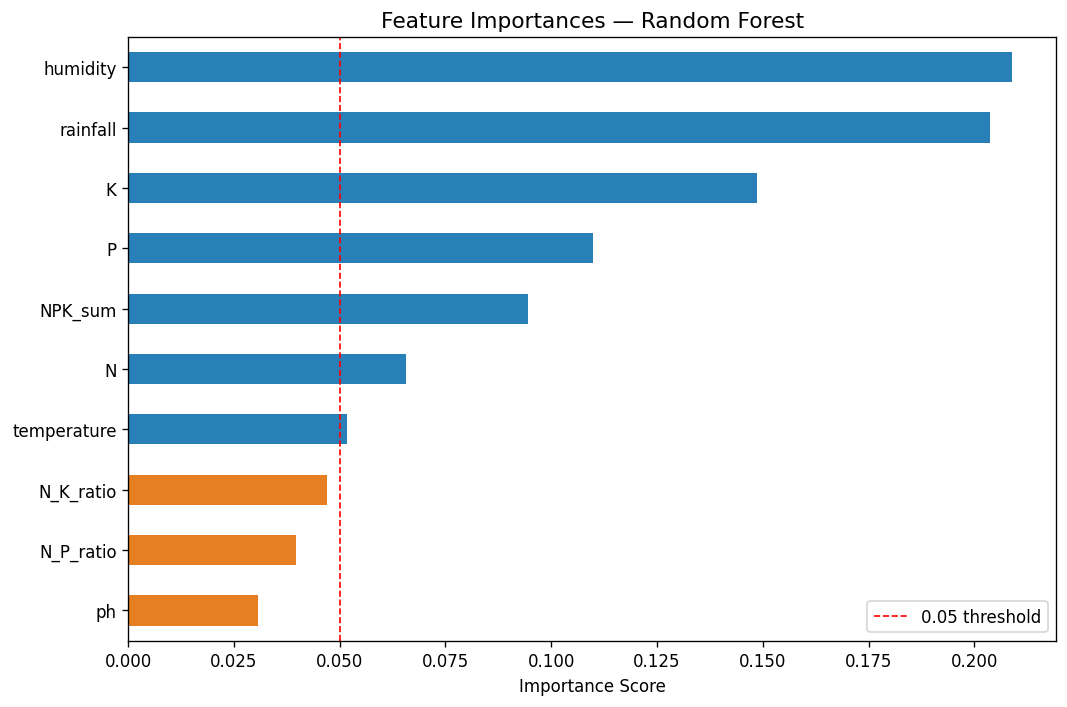


Feature importances:
humidity       0.2089
rainfall       0.2037
K              0.1485
P              0.1100
NPK_sum        0.0944
N              0.0656
temperature    0.0516
N_K_ratio      0.0470
N_P_ratio      0.0396
ph             0.0307
dtype: float64


In [22]:
# ── 5.2 Feature Importance via Random Forest ────────────────────────────
from sklearn.ensemble import RandomForestClassifier

all_features = features + ['NPK_sum', 'N_P_ratio', 'N_K_ratio']
X_all = df_eng[all_features]
y_all = df['label_encoded']

rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_all, y_all)

importances = pd.Series(rf_fs.feature_importances_, index=all_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e67e22' if i >= len(features) else '#2980b9' for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Feature Importances — Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=1, label='0.05 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("\nFeature importances:")
print(importances.sort_values(ascending=False).round(4))


In [23]:
# ── 5.3 SelectKBest (Statistical Feature Selection) ─────────────────────
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

scores = pd.Series(selector.scores_, index=features).sort_values(ascending=False)
print("SelectKBest F-scores (higher = more discriminative):")
print(scores.round(2))

# Decision: keep original 7 features (engineered ratios add minimal information)
print("\n✅ Final decision: use original 7 features.")
print("   Engineered ratio features added marginal importance — original features retained.")


SelectKBest F-scores (higher = more discriminative):
K              21755.15
humidity        2465.54
P               1470.45
N                721.63
rainfall         482.18
temperature       81.62
ph                49.65
dtype: float64

✅ Final decision: use original 7 features.
   Engineered ratio features added marginal importance — original features retained.


---
## Stage 6 — Model Building & Training
**Lead: Adithyan Biju (RF) · Abhita (KNN + DT)** | Issue #6


In [24]:
# ── 6.1 Random Forest ───────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Training Random Forest with GridSearchCV...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print(f"Best RF parameters : {rf_grid.best_params_}")
print(f"Best CV accuracy   : {rf_grid.best_score_*100:.2f}%")
joblib.dump(rf_best, 'models/random_forest.pkl')
print("✅ Model saved to models/random_forest.pkl")


Training Random Forest with GridSearchCV...
Best RF parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy   : 99.60%
✅ Model saved to models/random_forest.pkl


In [25]:
# ── 6.2 K-Nearest Neighbours ────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier

print("Training KNN with GridSearchCV...")
knn_params = {'n_neighbors': [3, 5, 7, 9, 11], 'metric': ['euclidean', 'manhattan']}
knn_grid = GridSearchCV(KNeighborsClassifier(),
                        knn_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
knn_grid.fit(X_train_scaled, y_train)   # KNN uses scaled features
knn_best = knn_grid.best_estimator_

print(f"Best KNN parameters : {knn_grid.best_params_}")
print(f"Best CV accuracy    : {knn_grid.best_score_*100:.2f}%")
joblib.dump(knn_best, 'models/knn.pkl')
print("✅ Model saved to models/knn.pkl")


Training KNN with GridSearchCV...
Best KNN parameters : {'metric': 'manhattan', 'n_neighbors': 5}
Best CV accuracy    : 97.90%
✅ Model saved to models/knn.pkl


In [26]:
# ── 6.3 Decision Tree ───────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree with GridSearchCV...")
dt_params = {
    'max_depth': [5, 10, 15, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

print(f"Best DT parameters : {dt_grid.best_params_}")
print(f"Best CV accuracy   : {dt_grid.best_score_*100:.2f}%")
joblib.dump(dt_best, 'models/decision_tree.pkl')
print("✅ Model saved to models/decision_tree.pkl")


Training Decision Tree with GridSearchCV...
Best DT parameters : {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 5}
Best CV accuracy   : 98.58%
✅ Model saved to models/decision_tree.pkl


---
## Stage 7 — Model Evaluation & Comparison
**Lead: Abhita** | Issue #7


In [ ]:
# ── 7.1 Accuracy Comparison ─────────────────────────────────────────────
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}

# RF — uses unscaled features
y_pred_rf = rf_best.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, y_pred_rf)

# KNN — uses scaled features
y_pred_knn = knn_best.predict(X_test_scaled)
results['KNN'] = accuracy_score(y_test, y_pred_knn)

# DT — uses unscaled features
y_pred_dt = dt_best.predict(X_test)
results['Decision Tree'] = accuracy_score(y_test, y_pred_dt)

print("=" * 40)
print(f"{'Model':<20} {'Accuracy':>10}")
print("=" * 40)
for model, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{model:<20} {acc*100:>9.2f}%")
print("=" * 40)


In [ ]:
# ── 7.2 Accuracy Bar Chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
models_list = list(results.keys())
accs = [results[m] * 100 for m in models_list]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(models_list, accs, color=colors, width=0.5, edgecolor='white')
ax.set_ylim(80, 102)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison', fontsize=13)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── 7.3 Classification Report — Best Model (RF) ─────────────────────────
print("Classification Report — Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


In [ ]:
# ── 7.4 Confusion Matrix ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
model_preds = [
    ('Random Forest', y_pred_rf),
    ('KNN', y_pred_knn),
    ('Decision Tree', y_pred_dt)
]
for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.3, annot_kws={'size': 7})
    ax.set_title(f'{name}\nAccuracy: {results[name]*100:.2f}%', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── 7.5 Decision Region Plot (2D via PCA) ───────────────────────────────
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Reduce to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
models_2d = [
    ('Random Forest', RandomForestClassifier(**rf_grid.best_params_, random_state=42)),
    ('KNN', KNeighborsClassifier(**knn_grid.best_params_)),
    ('Decision Tree', DecisionTreeClassifier(**dt_grid.best_params_, random_state=42))
]

cmap = ListedColormap(plt.cm.tab20.colors[:22])
h = 0.3

for ax, (name, model_2d) in zip(axes, models_2d):
    model_2d.fit(X_train_2d, y_train)
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap)
    scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                         c=y_test, cmap=cmap, edgecolor='k', s=20, linewidth=0.3)
    ax.set_title(f'{name}', fontsize=12)
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

plt.suptitle('Decision Regions (2D PCA Projection)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_regions.png', bbox_inches='tight')
plt.show()


---
## Stage 8 — Model Interpretation & Explainability
**Lead: Abhita** | Issue #8


In [ ]:
# ── Install SHAP if needed ───────────────────────────────────────────────
# Run this cell only once
# !pip install shap -q
import shap
print(f"SHAP version: {shap.__version__}")


In [ ]:
# ── 8.1 SHAP Summary Plot — Random Forest ───────────────────────────────
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=features,
                  class_names=le.classes_, show=False, max_display=7)
plt.title('SHAP Summary Plot — Random Forest (all classes)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot shows which features push predictions toward each crop.")


In [ ]:
# ── 8.2 SHAP Waterfall — Single Prediction Example ──────────────────────
# Pick first test sample and show why the model predicted what it did
sample_idx = 0
sample = X_test.iloc[[sample_idx]]
predicted_class_idx = rf_best.predict(sample)[0]
predicted_crop = le.inverse_transform([predicted_class_idx])[0]

print(f"Sample input:")
print(sample.to_string())
print(f"\nPredicted crop: {predicted_crop}")

shap_exp = shap.TreeExplainer(rf_best)(sample)
shap.waterfall_plot(shap_exp[0, :, predicted_class_idx], max_display=7, show=False)
plt.title(f'SHAP Waterfall — Why the model predicted: {predicted_crop}', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── 8.3 Decision Tree Feature Importance (visual) ───────────────────────
dt_importances = pd.Series(dt_best.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
dt_importances.plot(kind='barh', color='#8e44ad', ax=ax, edgecolor='white')
ax.set_title('Feature Importances — Decision Tree', fontsize=13)
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', bbox_inches='tight')
plt.show()


---
## Stage 9 — Deployment (Streamlit)
**Lead: [Your Name]** | Issue #9

The Streamlit app is located in `app/app.py`.

**Live deployment URL:** [Add your Streamlit Community Cloud URL here after deployment]

### App features:
- Sliders for all 7 input features (N, P, K, temperature, humidity, pH, rainfall)
- Predicted crop shown with confidence score
- Bar chart of probabilities for all 22 crops
- SHAP waterfall chart explaining the prediction
- Input validation to prevent crashes

### To run locally:
```bash
pip install -r requirements.txt
streamlit run app/app.py
```


---
## Stage 10 — Documentation
**Lead: Both members** | Issue #10

- ✅ README.md — complete with architecture diagram, results, screenshots, setup instructions
- ✅ PPT — uploaded to `/presentation/` folder in this repo  
- ✅ Individual GitHub profile screenshots — in `/individual_profiles/` folder
- ✅ requirements.txt — all dependencies listed
- ✅ This notebook — clean, reproducible, all stages covered

### Results Summary
| Model | Test Accuracy |
|---|---|
| Random Forest | *(fill after running)* |
| KNN | *(fill after running)* |
| Decision Tree | *(fill after running)* |

### Key Findings
*(Fill in after running all cells — e.g., which features were most important, which model won, interesting EDA findings)*
